# Lock-in + ODMR manuscript visualization

This notebook visualizes the June 3, 2026 ODMR sweep and live multipoint lock-in run. Edit the next cell to change titles, colors, line widths, figure sizes, saved output formats, or the input CSV names.

Source data:

- `data/odmr_sweeps/odmr_sweep_20260603_140233.csv`
- `data/lockin_multipoint/multipoint_lockin_live_20260603_140507.csv`

In [1]:
# Editable settings

# Input files, relative to nv_magnetometer_project/data/.
ODMR_CSV_NAME = "odmr_sweep_20260603_140233.csv"
LIVE_CSV_NAME = "multipoint_lockin_live_20260603_140507.csv"

# Figure titles. You can use these placeholders:
# {n_transitions}, {n_parked}, {odmr_csv_name}, {live_csv_name}
ODMR_TITLE = "New algorithm: {n_transitions} kept transitions, {n_parked} parked frequencies"
LOCKIN_TITLE = "Live two-point lock-in error signal - {live_csv_name}"
VECTOR_TITLE = "B-field vector reconstruction - {live_csv_name}"
MAGNITUDE_TITLE = "Total B-field shift magnitude over time"

# Axis labels.
ODMR_XLABEL = "Frequency (MHz)"
ODMR_YLABEL = "Normalized PL"
LOCKIN_XLABEL = "time (s)"
LOCKIN_YLABEL = "Delta f per block (MHz)"
VECTOR_XLABEL = "time (s)"
MAGNITUDE_YLABEL = "|Delta B| (uT)"

# Figure size and output controls.
FIGSIZE_ODMR = (12, 4)
FIGSIZE_LOCKIN = (13, 4.5)
FIGSIZE_VECTOR = (13, 7)
FIGSIZE_MAGNITUDE = (13, 3.5)
FIGURE_DPI = 300
SAVE_FIGURES = True
FIGURE_FORMATS = ("png", "pdf")

# Matplotlib style knobs.
MATPLOTLIB_STYLE = "default"
FONT_SIZE = 10
TITLE_SIZE = 13
LABEL_SIZE = 10
LEGEND_SIZE = 8
GRID_ALPHA = 0.30
LINE_WIDTH = 0.9
ODMR_LINE_WIDTH = 1.8
MARKER_SIZE = 6

# Colors.
ODMR_COLOR = "blue"
F_MINUS_COLOR = "orange"
F_PLUS_COLOR = "green"
CENTER_COLOR = "purple"
REJECTED_COLOR = "crimson"
LOCKIN_COLORMAP = "tab10"
VECTOR_COLORS = {
    "delta_Bx_uT": "tab:red",
    "delta_By_uT": "tab:green",
    "delta_Bz_uT": "tab:blue",
}
MAGNITUDE_COLOR = "purple"

# ODMR parking algorithm controls.
ODMR_SIGNAL_COLUMN = "photoluminescence_mw_on_ADC"
PARKED_FREQ_RANGE_MHZ = None  # Example: (2740, 3000)
SNR_THRESHOLD = 1.5
CLUSTER_MERGE_MHZ = 3.0
FIT_WINDOW_MHZ = 8.0
MAX_CENTERS = 8
PLACEMENT = "auto"  # "auto", "empirical_half_max", "empirical", "max_slope", "half_max"
ANNOTATE_ODMR_POINTS = True
SHOW_REJECTED_CENTERS = True

# Bias-field sign convention for vector reconstruction.
# The existing June 3 Lockin_module vector rows use negative local Bz for this run.
# Change to (1.0, 1.0, 1.0) if you want the raw estimator sign instead.
BIAS_FIELD_OVERRIDE_MT = None  # Example: (4.46245, 1.05556, -0.87216)
BIAS_FIELD_SIGN_CONVENTION = (1.0, 1.0, -1.0)

# Live lock-in plot controls.
LOCKIN_LEGEND_TEMPLATE = "block {block} (f0={f0_mhz:.1f} MHz)"
LOCKIN_LEGEND_NCOL = 4
LOCKIN_YLIM = None  # Example: (-0.8, 0.6)
VECTOR_YLIMS = {
    "delta_Bx_uT": None,
    "delta_By_uT": None,
    "delta_Bz_uT": None,
}
MAGNITUDE_YLIM = None

# Early frequency-shift despiking. This is applied before the 8-peak plot and
# its statistics table. Positions are zero-based DataFrame row positions.
LIVE_FREQ_DESPIKE_ENABLED = True
LIVE_FREQ_DESPIKE_ROW_POSITIONS = (38,)
LIVE_FREQ_DESPIKE_ABS_THRESHOLD_MHZ = 0.8
LIVE_FREQ_DESPIKE_WINDOW = 21

# Total-B despiking. Keeps the raw live CSV unchanged, then replaces the
# largest reconstructed |Delta B| sample with a local component-wise median.
TOTAL_B_DESPIKE_ENABLED = True
TOTAL_B_DESPIKE_N_POINTS = 1
TOTAL_B_DESPIKE_WINDOW = 21

In [2]:
from __future__ import annotations

import csv
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display
from matplotlib.lines import Line2D


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for root in (start, *start.parents):
        if (root / "data" / "odmr_sweeps").is_dir() and (root / "data" / "lockin_multipoint").is_dir():
            return root
        candidate = root / "nv_magnetometer_project"
        if (candidate / "data" / "odmr_sweeps").is_dir() and (candidate / "data" / "lockin_multipoint").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate nv_magnetometer_project from the current working directory.")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = DATA_ROOT / "manuscript plot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ODMR_CSV = DATA_ROOT / "odmr_sweeps" / ODMR_CSV_NAME
LIVE_CSV = DATA_ROOT / "lockin_multipoint" / LIVE_CSV_NAME
EXISTING_PLAN_CSV = DATA_ROOT / "lockin_multipoint" / f"parked_plan_{Path(ODMR_CSV_NAME).stem}.csv"

for path in (ODMR_CSV, LIVE_CSV):
    if not path.exists():
        raise FileNotFoundError(path)


def find_nv_toolkit_root(project_root: Path) -> Path:
    for root in (project_root, project_root.parent, *project_root.parents):
        candidate = root / "NV_Magnetometry_Software-main"
        if (candidate / "nv_toolkit" / "tui.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate NV_Magnetometry_Software-main/nv_toolkit.")


NV_TOOLKIT_ROOT = find_nv_toolkit_root(PROJECT_ROOT)
if str(NV_TOOLKIT_ROOT) not in sys.path:
    sys.path.insert(0, str(NV_TOOLKIT_ROOT))

plt.style.use(MATPLOTLIB_STYLE)
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"ODMR CSV: {ODMR_CSV}")
print(f"Live CSV: {LIVE_CSV}")
print(f"Existing parked plan CSV: {EXISTING_PLAN_CSV}")

Project root: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project
Output folder: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot
ODMR CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260603_140233.csv
Live CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260603_140507.csv
Existing parked plan CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260603_140233.csv

In [3]:
from nv_toolkit.peaks import (
    cluster_dip_candidates,
    collapse_candidate_clusters,
    detect_baseline_corrected_dip_candidates,
    fit_local_dips,
    reject_unpaired_peaks,
)
from nv_toolkit.tui import (
    OperatorConfig,
    ParkedFrequencyPlanEntry,
    _compute_live_snapshot,
    _estimate_bias_field_mT,
    _suggest_parked_frequencies,
    _write_parked_plan_csv,
)


def format_title(template: str, **values: object) -> str:
    try:
        return template.format(**values)
    except Exception:
        return template


def save_figure(fig: plt.Figure, stem: str) -> list[Path]:
    saved = []
    if not SAVE_FIGURES:
        return saved
    for suffix in FIGURE_FORMATS:
        out = OUTPUT_DIR / f"{stem}.{suffix}"
        fig.savefig(out, dpi=FIGURE_DPI, bbox_inches="tight")
        saved.append(out)
    return saved


def render_figure(fig: plt.Figure) -> None:
    """Display figures inline without requiring an interactive GUI backend."""
    display(fig)
    plt.close(fig)


def write_rows_csv(path: Path, rows: list[dict] | tuple[dict, ...]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        path.write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row:
            if key not in fieldnames:
                fieldnames.append(str(key))
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({key: row.get(key, "") for key in fieldnames})


def read_parked_plan_csv(path: Path) -> tuple[ParkedFrequencyPlanEntry, ...]:
    plan_df = pd.read_csv(path)
    entries = []
    for block_index, block in plan_df.groupby("block_index", sort=True):
        block = block.sort_values("point_in_block")
        minus = block.loc[block["point_in_block"] == 0].iloc[0]
        plus = block.loc[block["point_in_block"] == 1].iloc[0]
        entries.append(
            ParkedFrequencyPlanEntry(
                transition_index=int(minus["transition_index"]),
                center_mhz=float(minus["transition_center_mhz"]),
                linewidth_mhz=float(minus["linewidth_mhz"]),
                frequency_minus_mhz=float(minus["frequency_mhz"]),
                frequency_plus_mhz=float(plus["frequency_mhz"]),
                slope_minus_per_mhz=float(minus["slope_per_mhz"]),
                slope_plus_per_mhz=float(plus["slope_per_mhz"]),
            )
        )
    return tuple(entries)


def parked_plan_blocks_df(plan: tuple[ParkedFrequencyPlanEntry, ...]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "block_index": i,
                "transition_index": entry.transition_index,
                "center_mhz": entry.center_mhz,
                "linewidth_mhz": entry.linewidth_mhz,
                "f_minus_mhz": entry.frequency_minus_mhz,
                "f_plus_mhz": entry.frequency_plus_mhz,
                "slope_minus_per_mhz": entry.slope_minus_per_mhz,
                "slope_plus_per_mhz": entry.slope_plus_per_mhz,
            }
            for i, entry in enumerate(plan, start=1)
        ]
    )


def parked_plan_points_df(plan: tuple[ParkedFrequencyPlanEntry, ...]) -> pd.DataFrame:
    rows = []
    point_index = 0
    for block_index, entry in enumerate(plan, start=1):
        rows.append(
            {
                "block_index": block_index,
                "point_in_block": 0,
                "point_index": point_index,
                "transition_index": entry.transition_index,
                "transition_center_mhz": entry.center_mhz,
                "linewidth_mhz": entry.linewidth_mhz,
                "frequency_mhz": entry.frequency_minus_mhz,
                "slope_per_mhz": entry.slope_minus_per_mhz,
            }
        )
        point_index += 1
        rows.append(
            {
                "block_index": block_index,
                "point_in_block": 1,
                "point_index": point_index,
                "transition_index": entry.transition_index,
                "transition_center_mhz": entry.center_mhz,
                "linewidth_mhz": entry.linewidth_mhz,
                "frequency_mhz": entry.frequency_plus_mhz,
                "slope_per_mhz": entry.slope_plus_per_mhz,
            }
        )
        point_index += 1
    return pd.DataFrame(rows)

In [4]:
odmr_df = pd.read_csv(ODMR_CSV)
live_df = pd.read_csv(LIVE_CSV)

if "frequency_MHz" not in odmr_df.columns:
    raise ValueError(f"ODMR CSV is missing frequency_MHz. Columns: {list(odmr_df.columns)}")
if ODMR_SIGNAL_COLUMN not in odmr_df.columns:
    raise ValueError(f"ODMR CSV is missing {ODMR_SIGNAL_COLUMN}. Columns: {list(odmr_df.columns)}")
if "time_s" not in live_df.columns:
    raise ValueError(f"Live CSV is missing time_s. Columns: {list(live_df.columns)}")

delta_f_cols = sorted(c for c in live_df.columns if c.startswith("delta_f_mhz_b"))
peak_cols = sorted(c for c in live_df.columns if c.startswith("peak_") and c[5:7].isdigit() and c.endswith(tuple(f"{i:02d}" for i in range(1, 17))))

# Preserve the loaded measurement, then clean selected frequency-shift rows
# before the 8-peak plot and statistics table. The original source CSV is never edited.
live_df_raw = live_df.copy(deep=True)
freq_despike_summary_rows = []
if LIVE_FREQ_DESPIKE_ENABLED:
    _half_window = max(int(LIVE_FREQ_DESPIKE_WINDOW) // 2, 1)
    for _pos in LIVE_FREQ_DESPIKE_ROW_POSITIONS:
        _pos = int(_pos)
        if not 0 <= _pos < len(live_df):
            raise IndexError(f"Frequency despike row position {_pos} is outside 0..{len(live_df) - 1}")
        _start = max(0, _pos - _half_window)
        _stop = min(len(live_df), _pos + _half_window + 1)
        _neighbors = [p for p in range(_start, _stop) if p != _pos]
        for _delta_col in delta_f_cols:
            _block_suffix = _delta_col.split("_b")[-1]
            _paired_cols = [_delta_col, f"f_new_mhz_b{_block_suffix}"]
            for _col in _paired_cols:
                if _col not in live_df.columns:
                    continue
                _before = float(pd.to_numeric(pd.Series([live_df.iloc[_pos][_col]]), errors="coerce").iloc[0])
                _after = float(np.nanmedian(pd.to_numeric(live_df.iloc[_neighbors][_col], errors="coerce")))
                live_df.iat[_pos, live_df.columns.get_loc(_col)] = _after
                freq_despike_summary_rows.append(
                    {
                        "row_position": _pos,
                        "time_s": float(live_df.iloc[_pos]["time_s"]),
                        "column": _col,
                        "value_before": _before,
                        "value_after": _after,
                        "reason": "explicit_row",
                        "median_window_samples": int(LIVE_FREQ_DESPIKE_WINDOW),
                    }
                )

    # Also replace individual frequency-shift values outside the editable threshold.
    # Only the affected block and its paired f_new value are changed.
    for _delta_col in delta_f_cols:
        _raw_values = pd.to_numeric(live_df_raw[_delta_col], errors="coerce").to_numpy(dtype=float)
        _outlier_positions = np.flatnonzero(np.abs(_raw_values) > float(LIVE_FREQ_DESPIKE_ABS_THRESHOLD_MHZ))
        for _pos in _outlier_positions:
            _pos = int(_pos)
            if _pos in {int(p) for p in LIVE_FREQ_DESPIKE_ROW_POSITIONS}:
                continue
            _start = max(0, _pos - _half_window)
            _stop = min(len(live_df), _pos + _half_window + 1)
            _neighbors = [p for p in range(_start, _stop) if p != _pos]
            _block_suffix = _delta_col.split("_b")[-1]
            for _col in [_delta_col, f"f_new_mhz_b{_block_suffix}"]:
                if _col not in live_df.columns:
                    continue
                _before = float(pd.to_numeric(pd.Series([live_df.iloc[_pos][_col]]), errors="coerce").iloc[0])
                _after = float(np.nanmedian(pd.to_numeric(live_df.iloc[_neighbors][_col], errors="coerce")))
                live_df.iat[_pos, live_df.columns.get_loc(_col)] = _after
                freq_despike_summary_rows.append(
                    {
                        "row_position": _pos,
                        "time_s": float(live_df.iloc[_pos]["time_s"]),
                        "column": _col,
                        "value_before": _before,
                        "value_after": _after,
                        "reason": f"abs_delta_f_above_{LIVE_FREQ_DESPIKE_ABS_THRESHOLD_MHZ:g}_MHz",
                        "median_window_samples": int(LIVE_FREQ_DESPIKE_WINDOW),
                    }
                )

df_frequency_despike_summary = pd.DataFrame(freq_despike_summary_rows)
CLEANED_FREQ_SHIFT_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_frequency_shift_cleaned.csv"
FREQ_DESPIKE_SUMMARY_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_frequency_shift_despike_summary.csv"
live_df.to_csv(CLEANED_FREQ_SHIFT_CSV, index=False)
df_frequency_despike_summary.to_csv(FREQ_DESPIKE_SUMMARY_CSV, index=False)

print(f"ODMR rows: {len(odmr_df)}")
print(f"Live lock-in rows: {len(live_df)}")
print(f"Live duration: {float(live_df['time_s'].iloc[-1]):.2f} s")
print(f"Delta-f columns: {delta_f_cols}")
if LIVE_FREQ_DESPIKE_ENABLED:
    print(f"Frequency-shift despiked row positions: {list(LIVE_FREQ_DESPIKE_ROW_POSITIONS)}")
    print(f"Automatic |Delta f| threshold: {LIVE_FREQ_DESPIKE_ABS_THRESHOLD_MHZ:g} MHz")
    print(f"Cleaned frequency-shift CSV: {CLEANED_FREQ_SHIFT_CSV}")
    display(df_frequency_despike_summary)

display(odmr_df.head())
display(live_df.head())
if LIVE_FREQ_DESPIKE_ENABLED:
    display(FileLink(str(CLEANED_FREQ_SHIFT_CSV)))
    display(FileLink(str(FREQ_DESPIKE_SUMMARY_CSV)))

ODMR rows: 701
Live lock-in rows: 694
Live duration: 60.08 s
Delta-f columns: ['delta_f_mhz_b01', 'delta_f_mhz_b02', 'delta_f_mhz_b03', 'delta_f_mhz_b04', 'delta_f_mhz_b05', 'delta_f_mhz_b06', 'delta_f_mhz_b07', 'delta_f_mhz_b08']
Frequency-shift despiked row positions: [38]
Automatic |Delta f| threshold: 0.8 MHz
Cleaned frequency-shift CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_frequency_shift_cleaned.csv


,row_position,time_s,column,value_before,value_after,reason,median_window_samples
0,38,3.002729,delta_f_mhz_b01,-0.603025,-0.112867,explicit_row,21
1,38,3.002729,f_new_mhz_b01,2755.064018,2755.554177,explicit_row,21
2,38,3.002729,delta_f_mhz_b02,-0.296024,-0.006179,explicit_row,21
3,38,3.002729,f_new_mhz_b02,2786.621229,2786.911075,explicit_row,21
4,38,3.002729,delta_f_mhz_b03,-0.019111,-0.122222,explicit_row,21
5,38,3.002729,f_new_mhz_b03,2839.815053,2839.711942,explicit_row,21
6,38,3.002729,delta_f_mhz_b04,0.068545,-0.013656,explicit_row,21
7,38,3.002729,f_new_mhz_b04,2868.483922,2868.401722,explicit_row,21
8,38,3.002729,delta_f_mhz_b05,-0.106180,-0.175675,explicit_row,21
9,38,3.002729,f_new_mhz_b05,2889.230700,2889.161205,explicit_row,21


,frequency_MHz,photoluminescence_mw_on_ADC,photoluminescence_mw_off_ADC,contrast_ADC,contrast_percent
0,2700.000000,7256.054695,7251.454476,4.600219,0.063442
1,2700.500000,7255.599697,7251.729543,3.870155,0.053372
2,2701.000001,7254.980793,7249.977571,5.003222,0.069016
3,2701.500001,7255.058610,7251.395064,3.663546,0.050530
4,2702.000002,7255.637063,7250.640630,4.996433,0.068911


,batch,time_s,timestamp_epoch_s,acq_seconds,peak_01,peak_01_ref,peak_01_freq_mhz,peak_01_spike_sig,peak_01_spike_ref,peak_02,...,delta_f_mhz_b04,f_new_mhz_b04,delta_f_mhz_b05,f_new_mhz_b05,delta_f_mhz_b06,f_new_mhz_b06,delta_f_mhz_b07,f_new_mhz_b07,delta_f_mhz_b08,f_new_mhz_b08
0,0,0.006297,1.780514e+09,0.011900,7175.501065,7191.404819,2752.502041,False,False,7178.988964,...,0.052509,2868.467886,-0.145555,2889.191325,-0.140682,2916.360005,0.145553,2963.022929,0.288731,2988.395647
1,1,0.075232,1.780514e+09,0.012208,7177.879067,7194.303986,2752.502041,False,False,7179.427061,...,0.076397,2868.491775,-0.193604,2889.143275,-0.141254,2916.359433,0.162229,2963.039605,0.159447,2988.266363
2,2,0.143418,1.780514e+09,0.011901,7175.033495,7194.303986,2752.502041,False,False,7179.427061,...,0.076397,2868.491775,-0.193604,2889.143275,-0.141254,2916.359433,0.162229,2963.039605,0.159447,2988.266363
3,3,0.212303,1.780514e+09,0.012439,7174.640291,7189.467876,2752.502041,False,False,7178.505927,...,-0.058680,2868.356698,-0.037969,2889.298910,0.073085,2916.573772,0.153039,2963.030415,0.223867,2988.330783
4,4,0.297345,1.780514e+09,0.011956,7172.396302,7189.467876,2752.502041,False,False,7178.505927,...,-0.058680,2868.356698,-0.037969,2889.298910,0.073085,2916.573772,0.153039,2963.030415,0.223867,2988.330783


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_frequency_shift_cleaned.csv

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_frequency_shift_despike_summary.csv

In [5]:
freqs_mhz = odmr_df["frequency_MHz"].to_numpy(dtype=float)
mw_on = odmr_df[ODMR_SIGNAL_COLUMN].to_numpy(dtype=float)
measured = mw_on / float(np.nanmedian(mw_on))

algorithm_status = "computed"
rejected_fits = []

try:
    candidates = detect_baseline_corrected_dip_candidates(
        freqs_mhz,
        measured,
        min_prominence_sigma=SNR_THRESHOLD,
    )
    clusters = cluster_dip_candidates(candidates, merge_distance_mhz=CLUSTER_MERGE_MHZ)
    candidate_centers, cluster_rows = collapse_candidate_clusters(clusters, max_centers=MAX_CENTERS)

    if PARKED_FREQ_RANGE_MHZ is not None:
        low, high = float(PARKED_FREQ_RANGE_MHZ[0]), float(PARKED_FREQ_RANGE_MHZ[1])
        in_range = (candidate_centers >= low) & (candidate_centers <= high)
        candidate_centers = candidate_centers[in_range]
        if len(candidate_centers) == 0:
            raise RuntimeError("No candidate centers remain after PARKED_FREQ_RANGE_MHZ filtering.")

    local_fits = fit_local_dips(
        freqs_mhz,
        measured,
        candidate_centers,
        window_mhz=FIT_WINDOW_MHZ,
        hyperfine_merge_mhz=0.0,
    )
    kept_fits, rejected_fits = reject_unpaired_peaks(
        local_fits,
        (float(np.nanmin(freqs_mhz)), float(np.nanmax(freqs_mhz))),
    )
    kept_fits = sorted(kept_fits, key=lambda fit: fit.center_mhz)
    rejected_fits = sorted(rejected_fits, key=lambda fit: fit.center_mhz)
    if len(kept_fits) == 0:
        raise RuntimeError("Parking algorithm rejected every fitted center.")

    transition_centers = np.asarray([fit.center_mhz for fit in kept_fits], dtype=float)
    parked_plan = _suggest_parked_frequencies(
        freqs_mhz,
        measured,
        transition_centers,
        placement=PLACEMENT,
    )
except Exception as exc:
    algorithm_status = f"fallback to existing plan: {exc}"
    if not EXISTING_PLAN_CSV.exists():
        raise
    parked_plan = read_parked_plan_csv(EXISTING_PLAN_CSV)
    transition_centers = np.asarray([entry.center_mhz for entry in parked_plan], dtype=float)
    candidate_centers = transition_centers.copy()

try:
    BIAS_MT = np.asarray(_estimate_bias_field_mT(freqs_mhz, measured, transition_centers), dtype=float)
except Exception as exc:
    print(f"Bias field estimate failed; using zero bias for reconstruction. Reason: {exc}")
    BIAS_MT = np.zeros(3, dtype=float)
if BIAS_FIELD_OVERRIDE_MT is not None:
    BIAS_MT = np.asarray(BIAS_FIELD_OVERRIDE_MT, dtype=float)
else:
    BIAS_MT = BIAS_MT * np.asarray(BIAS_FIELD_SIGN_CONVENTION, dtype=float)

COMPUTED_PLAN_CSV = OUTPUT_DIR / f"computed_parked_plan_{Path(ODMR_CSV_NAME).stem}.csv"
_write_parked_plan_csv(COMPUTED_PLAN_CSV, parked_plan)

plan_blocks = parked_plan_blocks_df(parked_plan)
plan_points = parked_plan_points_df(parked_plan)
parked_freqs_mhz = plan_points.sort_values("point_index")["frequency_mhz"].to_numpy(dtype=float)

print(f"Parking algorithm status: {algorithm_status}")
print(f"Kept centers: {np.round(transition_centers, 3).tolist()}")
print(f"Rejected centers: {[round(float(fit.center_mhz), 3) for fit in rejected_fits]}")
print(f"Computed parked plan CSV: {COMPUTED_PLAN_CSV}")
print(f"Bias estimate (mT): {BIAS_MT[0]:+.5f}, {BIAS_MT[1]:+.5f}, {BIAS_MT[2]:+.5f}")

display(plan_blocks)
display(plan_points)
display(FileLink(str(COMPUTED_PLAN_CSV)))

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/NV_Magnetometry_Software-main/nv_toolkit/peaks.py:444: PeakPropertyWarning: some peaks have a prominence of 0
  widths_samples, _, _, _ = peak_widths(inverted, [peak_idx], rel_height=0.5)
/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/NV_Magnetometry_Software-main/nv_toolkit/peaks.py:444: PeakPropertyWarning: some peaks have a width of 0
  widths_samples, _, _, _ = peak_widths(inverted, [peak_idx], rel_height=0.5)


Parking algorithm status: computed
Kept centers: [2756.284, 2787.464, 2840.78, 2868.903, 2890.039, 2916.158, 2963.347, 2988.654]
Rejected centers: []
Computed parked plan CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/computed_parked_plan_odmr_sweep_20260603_140233.csv
Bias estimate (mT): +4.46245, +1.05558, +0.87217


,block_index,transition_index,center_mhz,linewidth_mhz,f_minus_mhz,f_plus_mhz,slope_minus_per_mhz,slope_plus_per_mhz
0,1,0,2756.284988,9.243361,2752.502041,2760.000046,-0.001970,0.001757
1,2,1,2787.428999,9.278950,2783.821798,2791.000069,-0.002639,0.002419
2,3,2,2840.794790,13.875386,2837.115278,2844.500110,-0.000851,0.000698
3,4,3,2868.914248,9.045142,2864.391677,2873.436819,-0.000880,0.000646
4,5,4,2890.046942,10.666046,2884.713919,2895.379965,-0.000995,0.000620
5,6,5,2916.156467,10.443545,2910.934694,2921.378240,-0.000736,0.000738
6,7,6,2963.312877,8.262380,2959.628612,2967.000204,-0.002515,0.002202
7,8,7,2988.651731,10.015706,2985.000217,2992.354620,-0.001769,0.001602


,block_index,point_in_block,point_index,transition_index,transition_center_mhz,linewidth_mhz,frequency_mhz,slope_per_mhz
0,1,0,0,0,2756.284988,9.243361,2752.502041,-0.001970
1,1,1,1,0,2756.284988,9.243361,2760.000046,0.001757
2,2,0,2,1,2787.428999,9.278950,2783.821798,-0.002639
3,2,1,3,1,2787.428999,9.278950,2791.000069,0.002419
4,3,0,4,2,2840.794790,13.875386,2837.115278,-0.000851
5,3,1,5,2,2840.794790,13.875386,2844.500110,0.000698
6,4,0,6,3,2868.914248,9.045142,2864.391677,-0.000880
7,4,1,7,3,2868.914248,9.045142,2873.436819,0.000646
8,5,0,8,4,2890.046942,10.666046,2884.713919,-0.000995
9,5,1,9,4,2890.046942,10.666046,2895.379965,0.000620


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/computed_parked_plan_odmr_sweep_20260603_140233.csv

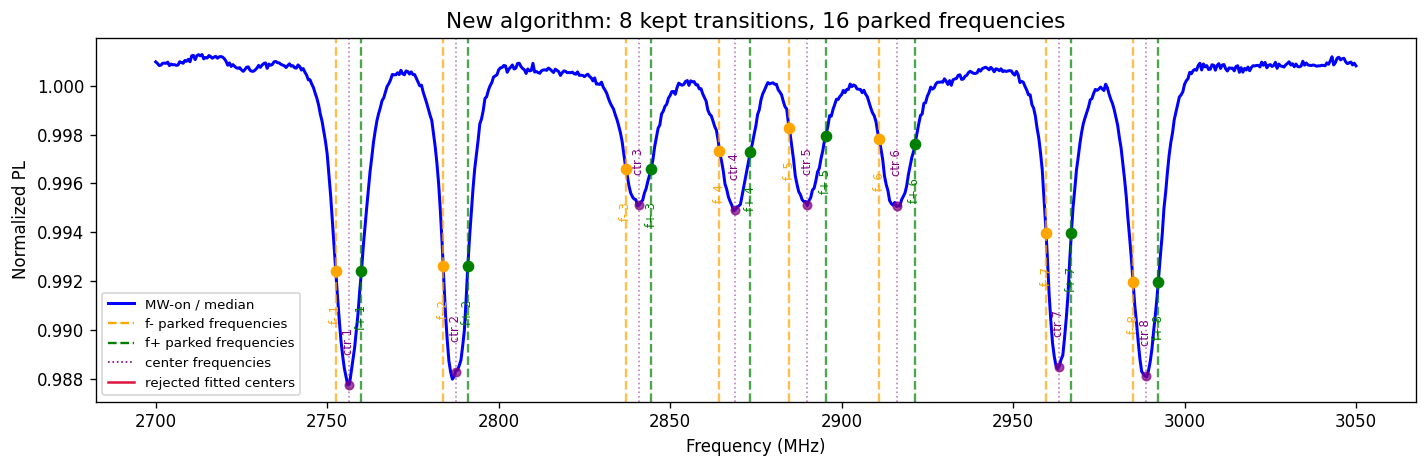

Saved: ['/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/01_odmr_parked_frequency_algorithm.png', '/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/01_odmr_parked_frequency_algorithm.pdf']


In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE_ODMR)
ax.plot(freqs_mhz, measured, color=ODMR_COLOR, lw=ODMR_LINE_WIDTH, label="MW-on / median")
ax.set_xlabel(ODMR_XLABEL)
ax.set_ylabel(ODMR_YLABEL)
ax.set_title(
    format_title(
        ODMR_TITLE,
        n_transitions=len(parked_plan),
        n_parked=len(plan_points),
        odmr_csv_name=ODMR_CSV.name,
        live_csv_name=LIVE_CSV.name,
    )
)

if PARKED_FREQ_RANGE_MHZ is not None:
    ax.axvspan(PARKED_FREQ_RANGE_MHZ[0], PARKED_FREQ_RANGE_MHZ[1], color="yellow", alpha=0.08, zorder=0)

for i, entry in enumerate(parked_plan, start=1):
    y_minus = float(np.interp(entry.frequency_minus_mhz, freqs_mhz, measured))
    y_plus = float(np.interp(entry.frequency_plus_mhz, freqs_mhz, measured))
    y_center = float(np.interp(entry.center_mhz, freqs_mhz, measured))

    ax.axvline(entry.frequency_minus_mhz, color=F_MINUS_COLOR, ls="--", lw=1.4, alpha=0.7)
    ax.axvline(entry.frequency_plus_mhz, color=F_PLUS_COLOR, ls="--", lw=1.4, alpha=0.7)
    ax.axvline(entry.center_mhz, color=CENTER_COLOR, ls=":", lw=1.0, alpha=0.5)

    ax.plot(entry.frequency_minus_mhz, y_minus, "o", color=F_MINUS_COLOR, markersize=MARKER_SIZE, zorder=5)
    ax.plot(entry.frequency_plus_mhz, y_plus, "o", color=F_PLUS_COLOR, markersize=MARKER_SIZE, zorder=5)
    ax.plot(entry.center_mhz, y_center, "o", color=CENTER_COLOR, markersize=max(4, MARKER_SIZE - 1), alpha=0.7, zorder=5)

    if ANNOTATE_ODMR_POINTS:
        ax.annotate(
            f"f- {i}", xy=(entry.frequency_minus_mhz, y_minus),
            xytext=(0, -20), textcoords="offset points",
            ha="center", va="top", fontsize=max(6, LEGEND_SIZE - 1),
            color=F_MINUS_COLOR, rotation=90,
        )
        ax.annotate(
            f"f+ {i}", xy=(entry.frequency_plus_mhz, y_plus),
            xytext=(0, -20), textcoords="offset points",
            ha="center", va="top", fontsize=max(6, LEGEND_SIZE - 1),
            color=F_PLUS_COLOR, rotation=90,
        )
        ax.annotate(
            f"ctr {i}", xy=(entry.center_mhz, y_center),
            xytext=(0, 18), textcoords="offset points",
            ha="center", va="bottom", fontsize=max(6, LEGEND_SIZE - 1),
            color=CENTER_COLOR, rotation=90,
        )

if SHOW_REJECTED_CENTERS:
    for fit in rejected_fits:
        ax.axvline(float(fit.center_mhz), color=REJECTED_COLOR, lw=1.5, alpha=0.8)

legend_elements = [
    Line2D([0], [0], color=ODMR_COLOR, lw=ODMR_LINE_WIDTH, label="MW-on / median"),
    Line2D([0], [0], color=F_MINUS_COLOR, ls="--", lw=1.4, label="f- parked frequencies"),
    Line2D([0], [0], color=F_PLUS_COLOR, ls="--", lw=1.4, label="f+ parked frequencies"),
    Line2D([0], [0], color=CENTER_COLOR, ls=":", lw=1.0, label="center frequencies"),
    Line2D([0], [0], color=REJECTED_COLOR, lw=1.5, label="rejected fitted centers"),
]
ax.legend(handles=legend_elements, loc="best")
ax.grid(False)
fig.tight_layout()
saved = save_figure(fig, "01_odmr_parked_frequency_algorithm")
render_figure(fig)
print("Saved:", [str(path) for path in saved])

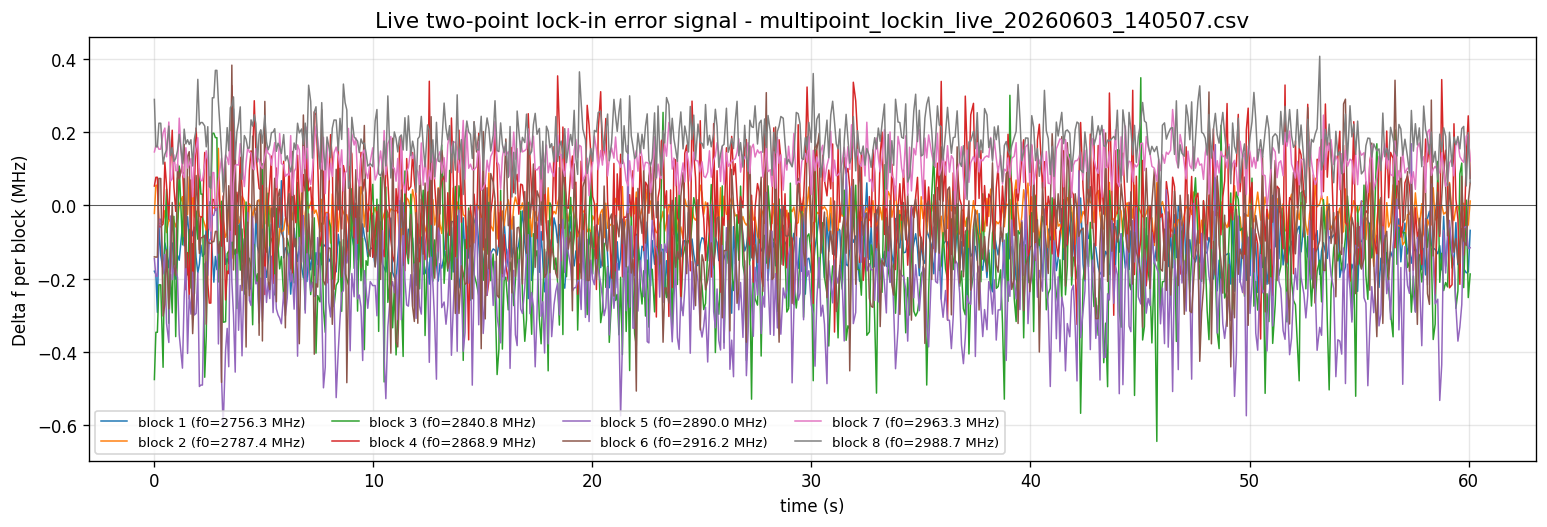

Saved: ['/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/02_live_lockin_delta_f.png', '/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/02_live_lockin_delta_f.pdf']


,block,peak_center_mhz,f_minus_mhz,f_plus_mhz,n_samples,delta_f_mean_mhz,delta_f_median_mhz,delta_f_std_mhz,delta_f_min_mhz,delta_f_max_mhz
0,1,2756.284988,2752.502041,2760.000046,694,-0.121214,-0.122792,0.059995,-0.294365,0.263086
1,2,2787.428999,2783.821798,2791.000069,694,-0.026534,-0.025374,0.039635,-0.166328,0.155326
2,3,2840.794790,2837.115278,2844.500110,694,-0.158132,-0.163097,0.141600,-0.643977,0.347911
3,4,2868.914248,2864.391677,2873.436819,694,0.007889,0.016074,0.133061,-0.366941,0.352973
4,5,2890.046942,2884.713919,2895.379965,694,-0.228837,-0.226993,0.125071,-0.605873,0.167814
5,6,2916.156467,2910.934694,2921.378240,694,-0.080257,-0.080686,0.141585,-0.506724,0.382242
6,7,2963.312877,2959.628612,2967.000204,694,0.118143,0.120467,0.048056,-0.097866,0.261291
7,8,2988.651731,2985.000217,2992.354620,694,0.178640,0.178723,0.061579,-0.024197,0.406450


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_peak_frequency_change_stats.csv

In [7]:
block_ids = sorted(int(col.split("_b")[-1]) for col in delta_f_cols)
time_s = live_df["time_s"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=FIGSIZE_LOCKIN)
cmap = plt.get_cmap(LOCKIN_COLORMAP)
colors = [cmap(i % max(1, cmap.N)) for i in range(len(block_ids))]

for i, block in enumerate(block_ids):
    row = plan_blocks.loc[plan_blocks["block_index"] == block]
    f0 = float(row["center_mhz"].iloc[0]) if not row.empty else float("nan")
    f_minus = float(row["f_minus_mhz"].iloc[0]) if not row.empty else float("nan")
    f_plus = float(row["f_plus_mhz"].iloc[0]) if not row.empty else float("nan")
    label = LOCKIN_LEGEND_TEMPLATE.format(
        block=block,
        f0_mhz=f0,
        f_minus_mhz=f_minus,
        f_plus_mhz=f_plus,
    )
    ax.plot(
        time_s,
        live_df[f"delta_f_mhz_b{block:02d}"].to_numpy(dtype=float),
        color=colors[i],
        lw=LINE_WIDTH,
        label=label,
    )

ax.axhline(0, color="0.35", lw=0.6)
ax.set_xlabel(LOCKIN_XLABEL)
ax.set_ylabel(LOCKIN_YLABEL)
ax.set_title(
    format_title(
        LOCKIN_TITLE,
        n_transitions=len(parked_plan),
        n_parked=len(plan_points),
        odmr_csv_name=ODMR_CSV.name,
        live_csv_name=LIVE_CSV.name,
    )
)
if LOCKIN_YLIM is not None:
    ax.set_ylim(*LOCKIN_YLIM)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(ncol=LOCKIN_LEGEND_NCOL, loc="best")
fig.tight_layout()
saved = save_figure(fig, "02_live_lockin_delta_f")
render_figure(fig)
print("Saved:", [str(path) for path in saved])

# DataFrame table: frequency-change statistics for the 8 fitted peaks/blocks.
peak_frequency_stats_rows = []
for block in block_ids:
    col = f"delta_f_mhz_b{block:02d}"
    values = pd.to_numeric(live_df[col], errors="coerce")
    row = plan_blocks.loc[plan_blocks["block_index"] == block]
    peak_frequency_stats_rows.append(
        {
            "block": block,
            "peak_center_mhz": float(row["center_mhz"].iloc[0]) if not row.empty else np.nan,
            "f_minus_mhz": float(row["f_minus_mhz"].iloc[0]) if not row.empty else np.nan,
            "f_plus_mhz": float(row["f_plus_mhz"].iloc[0]) if not row.empty else np.nan,
            "n_samples": int(values.count()),
            "delta_f_mean_mhz": float(values.mean()),
            "delta_f_median_mhz": float(values.median()),
            "delta_f_std_mhz": float(values.std()),
            "delta_f_min_mhz": float(values.min()),
            "delta_f_max_mhz": float(values.max()),
        }
    )

df_peak_frequency_stats = pd.DataFrame(peak_frequency_stats_rows)
PEAK_FREQ_STATS_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_peak_frequency_change_stats.csv"
df_peak_frequency_stats.to_csv(PEAK_FREQ_STATS_CSV, index=False)

display(df_peak_frequency_stats)
display(FileLink(str(PEAK_FREQ_STATS_CSV)))

In [8]:
# Build the normalized wide-format file expected by nv_toolkit._compute_live_snapshot.
# Each signal is divided by its paired reference shot so the live data matches the
# normalized ODMR calibration scale.
wide_recon = pd.DataFrame({"time_s": live_df["time_s"].to_numpy(dtype=float)})
for point_index in range(len(parked_freqs_mhz)):
    col = f"peak_{point_index + 1:02d}"
    ref_col = f"{col}_ref"
    if col not in live_df.columns or ref_col not in live_df.columns:
        raise ValueError(f"Live CSV is missing {col} or {ref_col}")
    wide_recon[col] = live_df[col].to_numpy(dtype=float) / live_df[ref_col].to_numpy(dtype=float)

WIDE_RECON_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_wide_for_reconstruction.csv"
wide_recon.to_csv(WIDE_RECON_CSV, index=False)

config = OperatorConfig(
    full_scan_path=ODMR_CSV,
    parked_data_path=WIDE_RECON_CSV,
    parked_format="wide",
    bias_field_mT=np.asarray(BIAS_MT, dtype=float),
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    transition_centers_mhz=np.asarray(transition_centers, dtype=float),
    parked_plan=tuple(parked_plan),
    plan_csv_path=COMPUTED_PLAN_CSV,
    wide_template_path=OUTPUT_DIR / "parked_template_wide.csv",
    long_template_path=OUTPUT_DIR / "parked_template_long.csv",
    poll_interval_s=0.0,
)

snapshot = _compute_live_snapshot(config)
if snapshot.status == "error":
    raise RuntimeError(snapshot.message)

VECTOR_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_vector_rows.csv"
VECTOR_RAW_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_vector_rows_raw.csv"
PROJECTION_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_projection_rows.csv"
DESPIKE_SUMMARY_CSV = OUTPUT_DIR / f"{LIVE_CSV.stem}_total_B_despike_summary.csv"
write_rows_csv(VECTOR_RAW_CSV, snapshot.vector_rows)
write_rows_csv(VECTOR_CSV, snapshot.vector_rows)
write_rows_csv(PROJECTION_CSV, snapshot.projection_rows)

df_vec = pd.DataFrame(snapshot.vector_rows)
df_proj = pd.DataFrame(snapshot.projection_rows)

despike_summary = pd.DataFrame()
if TOTAL_B_DESPIKE_ENABLED and not df_vec.empty:
    _components = ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"]
    if not all(comp in df_vec.columns for comp in _components):
        raise RuntimeError(f"Cannot despike total B because vector columns are missing: {_components}")

    _values = df_vec[_components].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    _magnitude = np.sqrt(np.nansum(_values**2, axis=1))
    _n_replace = min(max(int(TOTAL_B_DESPIKE_N_POINTS), 0), len(df_vec))
    _half_window = max(int(TOTAL_B_DESPIKE_WINDOW) // 2, 1)
    _positions = np.argsort(_magnitude)[-_n_replace:][::-1] if _n_replace else []
    _summary_rows = []

    for _pos in _positions:
        _start = max(0, int(_pos) - _half_window)
        _stop = min(len(df_vec), int(_pos) + _half_window + 1)
        _neighbor_positions = np.array([p for p in range(_start, _stop) if p != int(_pos)], dtype=int)
        if len(_neighbor_positions) == 0:
            _neighbor_positions = np.array([p for p in range(len(df_vec)) if p != int(_pos)], dtype=int)

        _row = {
            "row_index": int(df_vec.index[int(_pos)]),
            "position": int(_pos),
            "timestamp_epoch_s": float(df_vec.iloc[int(_pos)].get("timestamp_epoch_s", np.nan)),
            "magnitude_before_uT": float(_magnitude[int(_pos)]),
        }
        _replacement_components = []
        for _comp in _components:
            _before = float(pd.to_numeric(pd.Series([df_vec.iloc[int(_pos)][_comp]]), errors="coerce").iloc[0])
            _after = float(np.nanmedian(pd.to_numeric(df_vec.iloc[_neighbor_positions][_comp], errors="coerce")))
            df_vec.iat[int(_pos), df_vec.columns.get_loc(_comp)] = _after
            _replacement_components.append(_after)
            _row[f"{_comp}_before"] = _before
            _row[f"{_comp}_after"] = _after
        _row["magnitude_after_uT"] = float(np.sqrt(np.sum(np.asarray(_replacement_components, dtype=float) ** 2)))
        _row["median_window_samples"] = int(TOTAL_B_DESPIKE_WINDOW)
        _summary_rows.append(_row)

    despike_summary = pd.DataFrame(_summary_rows)
    despike_summary.to_csv(DESPIKE_SUMMARY_CSV, index=False)
    df_vec.to_csv(VECTOR_CSV, index=False)

print(f"Reconstruction status: {snapshot.status}")
print(f"Samples: {snapshot.sample_count}; rank-ok: {snapshot.ok_count}")
print(f"Wide reconstruction CSV: {WIDE_RECON_CSV}")
print(f"Raw vector CSV: {VECTOR_RAW_CSV}")
print(f"Vector CSV: {VECTOR_CSV}")
print(f"Projection CSV: {PROJECTION_CSV}")
if TOTAL_B_DESPIKE_ENABLED:
    print(f"Total-B despike summary CSV: {DESPIKE_SUMMARY_CSV}")
    display(despike_summary)
display(df_vec.head())
display(FileLink(str(WIDE_RECON_CSV)))
display(FileLink(str(VECTOR_RAW_CSV)))
display(FileLink(str(VECTOR_CSV)))
display(FileLink(str(PROJECTION_CSV)))
if TOTAL_B_DESPIKE_ENABLED:
    display(FileLink(str(DESPIKE_SUMMARY_CSV)))

Reconstruction status: ok
Samples: 694; rank-ok: 694
Wide reconstruction CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_wide_for_reconstruction.csv
Raw vector CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_vector_rows_raw.csv
Vector CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_vector_rows.csv
Projection CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_1

,row_index,position,timestamp_epoch_s,magnitude_before_uT,delta_Bx_uT_before,delta_Bx_uT_after,delta_By_uT_before,delta_By_uT_after,delta_Bz_uT_before,delta_Bz_uT_after,magnitude_after_uT,median_window_samples
0,38,38,3.002729,26.669078,15.643088,4.693585,-19.614424,0.881657,9.044773,2.932064,5.603933,21


,save_id,timestamp_epoch_s,n_channels,rank,condition_number,residual_norm_uT,delta_Bx_uT,delta_By_uT,delta_Bz_uT,status
0,000000,0.006297,8,3,9.445316,19.388225,6.902257,5.919642,5.169340,ok
1,000001,0.075232,8,3,9.445316,19.171514,5.134173,6.566581,5.426992,ok
2,000002,0.143418,8,3,9.445316,17.897986,6.361128,4.829603,7.121569,ok
3,000003,0.212303,8,3,9.445316,11.305146,5.160432,8.378480,1.542277,ok
4,000004,0.297345,8,3,9.445316,9.044091,6.128647,7.007795,2.879502,ok


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_wide_for_reconstruction.csv

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_vector_rows_raw.csv

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_vector_rows.csv

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_projection_rows.csv

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/multipoint_lockin_live_20260603_140507_total_B_despike_summary.csv

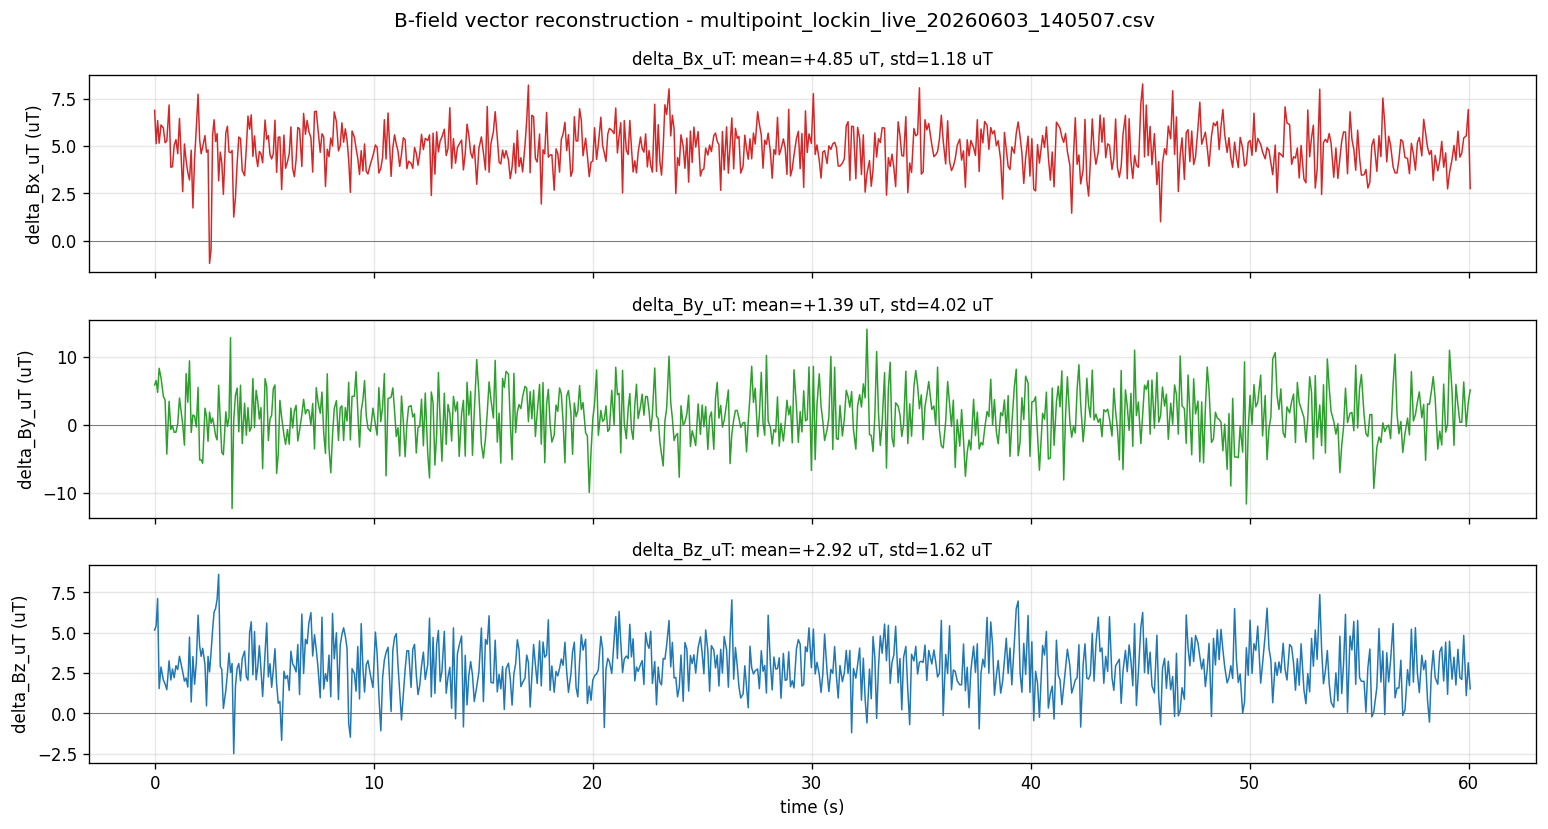

Saved: ['/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/03_bfield_vector_reconstruction.png', '/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/03_bfield_vector_reconstruction.pdf']


In [9]:
if df_vec.empty:
    raise RuntimeError("No vector rows were reconstructed.")

if "time_s" in df_vec.columns:
    t_vec = pd.to_numeric(df_vec["time_s"], errors="coerce").to_numpy(dtype=float)
elif "timestamp_epoch_s" in df_vec.columns:
    ts = pd.to_numeric(df_vec["timestamp_epoch_s"], errors="coerce").to_numpy(dtype=float)
    t_vec = ts - ts[0]
else:
    t_vec = np.arange(len(df_vec), dtype=float)

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_VECTOR, sharex=True)
for ax, comp in zip(axes, ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"]):
    values = pd.to_numeric(df_vec[comp], errors="coerce").to_numpy(dtype=float)
    ax.plot(t_vec, values, color=VECTOR_COLORS.get(comp, "black"), lw=LINE_WIDTH)
    ax.axhline(0, color="0.4", lw=0.5)
    ax.set_ylabel(f"{comp} (uT)")
    ax.grid(True, alpha=GRID_ALPHA)
    if VECTOR_YLIMS.get(comp) is not None:
        ax.set_ylim(*VECTOR_YLIMS[comp])
    mu = float(np.nanmean(values))
    sd = float(np.nanstd(values, ddof=1))
    ax.set_title(f"{comp}: mean={mu:+.2f} uT, std={sd:.2f} uT", fontsize=LABEL_SIZE)

axes[-1].set_xlabel(VECTOR_XLABEL)
fig.suptitle(
    format_title(
        VECTOR_TITLE,
        n_transitions=len(parked_plan),
        n_parked=len(plan_points),
        odmr_csv_name=ODMR_CSV.name,
        live_csv_name=LIVE_CSV.name,
    )
)
fig.tight_layout()
saved = save_figure(fig, "03_bfield_vector_reconstruction")
render_figure(fig)
print("Saved:", [str(path) for path in saved])

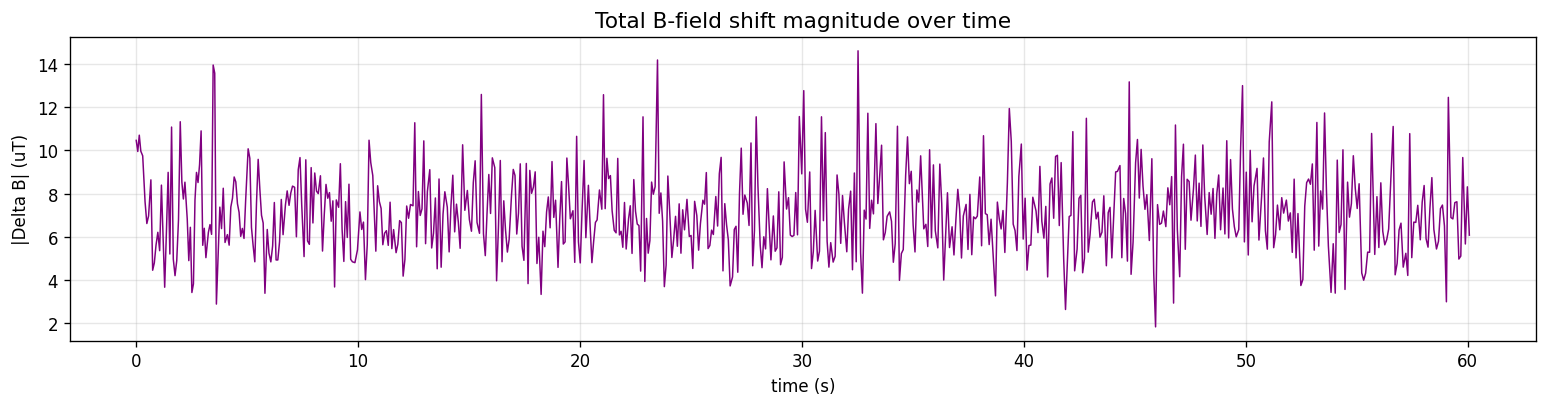

Saved: ['/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/04_total_bfield_shift_magnitude.png', '/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/manuscript plot/04_total_bfield_shift_magnitude.pdf']


In [10]:
required = ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"]
if not all(col in df_vec.columns for col in required):
    raise RuntimeError(f"Vector table is missing one of {required}")

bx = pd.to_numeric(df_vec["delta_Bx_uT"], errors="coerce").to_numpy(dtype=float)
by = pd.to_numeric(df_vec["delta_By_uT"], errors="coerce").to_numpy(dtype=float)
bz = pd.to_numeric(df_vec["delta_Bz_uT"], errors="coerce").to_numpy(dtype=float)
b_magnitude = np.sqrt(bx**2 + by**2 + bz**2)

fig, ax = plt.subplots(figsize=FIGSIZE_MAGNITUDE)
ax.plot(t_vec, b_magnitude, color=MAGNITUDE_COLOR, lw=LINE_WIDTH)
ax.set_xlabel(VECTOR_XLABEL)
ax.set_ylabel(MAGNITUDE_YLABEL)
ax.set_title(
    format_title(
        MAGNITUDE_TITLE,
        n_transitions=len(parked_plan),
        n_parked=len(plan_points),
        odmr_csv_name=ODMR_CSV.name,
        live_csv_name=LIVE_CSV.name,
    )
)
if MAGNITUDE_YLIM is not None:
    ax.set_ylim(*MAGNITUDE_YLIM)
ax.grid(True, alpha=GRID_ALPHA)
fig.tight_layout()
saved = save_figure(fig, "04_total_bfield_shift_magnitude")
render_figure(fig)
print("Saved:", [str(path) for path in saved])

## Output files

The notebook saves derived CSVs and exported figures to `data/manuscript plot/`. Edit the first code cell and rerun the notebook to adjust titles, labels, colors, line widths, figure sizes, axis limits, or output formats.